# Setup

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('mental_health_burnout_tech_2026.csv')
df.head()

,employee_id,age,gender,country,job_role,seniority_level,years_experience,years_at_company,company_size,industry,...,autonomy_score,stress_score,burnout_score,phq9_score,phq9_category,gad7_score,gad7_category,burnout_level,seeks_mental_health_support,job_change_intention
0,1,33,Male,India,Software Engineer,Lead,11,6.4,Small (51-200),Healthcare Tech,...,6.1,10.0,10.0,19,Moderately Severe (15-19),12,Moderate (10-14),Severe,1,1
1,2,24,Non-binary,USA,Full Stack Developer,Manager,0,5.7,Startup (1-50),Fintech,...,5.4,9.3,7.0,8,Mild (5-9),6,Mild (5-9),High,1,1
2,3,36,Prefer not to say,USA,Software Engineer,Lead,14,5.6,Mid (201-1000),Fintech,...,4.1,8.9,8.5,8,Mild (5-9),9,Mild (5-9),Severe,0,1
3,4,38,Non-binary,USA,Software Engineer,Lead,14,1.2,Mid (201-1000),SaaS / Cloud,...,7.3,10.0,10.0,14,Moderate (10-14),11,Moderate (10-14),Severe,0,1
4,5,22,Non-binary,France,ML Engineer,Junior,0,3.0,Small (51-200),AI / ML Startup,...,4.4,7.7,5.4,8,Mild (5-9),0,Minimal (0-4),Moderate,1,0


# Exploratory Data Analysis (EDA)

In [3]:
print("\nDataset Information:")
df.info()

print("\nDataset Description (numerical columns):")
display(df.describe(include='number'))

print("\nDataset Description (categorical columns):")
display(df.describe(include=['object', 'string']))


Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 36 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   employee_id                  100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  str    
 3   country                      100000 non-null  str    
 4   job_role                     100000 non-null  str    
 5   seniority_level              100000 non-null  str    
 6   years_experience             100000 non-null  int64  
 7   years_at_company             100000 non-null  float64
 8   company_size                 100000 non-null  str    
 9   industry                     100000 non-null  str    
 10  work_mode                    100000 non-null  str    
 11  salary_usd                   100000 non-null  int64  
 12  work_hours_per_week          100000 non-null  in

,employee_id,age,years_experience,years_at_company,salary_usd,work_hours_per_week,meetings_per_day,team_size,sleep_hours_per_night,exercise_days_per_week,...,job_satisfaction_score,social_support_score,deadline_pressure_score,autonomy_score,stress_score,burnout_score,phq9_score,gad7_score,seeks_mental_health_support,job_change_intention
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,31.305670,9.343690,2.492581,83285.490230,47.104080,4.162244,18.009650,6.102392,2.968730,...,4.834823,5.383951,6.385095,5.836528,7.055399,5.401675,6.27194,5.118920,0.497890,0.320020
std,28867.657797,6.427924,6.401543,2.450426,39392.584827,5.246902,1.937849,12.607473,0.998808,1.772762,...,1.920796,1.832774,1.769242,1.836491,2.128530,2.668425,4.95427,4.007513,0.499998,0.466486
min,1.000000,22.000000,0.000000,0.100000,40000.000000,35.000000,0.000000,2.000000,3.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,26.000000,4.000000,0.700000,46018.250000,44.000000,2.800000,8.000000,5.400000,2.000000,...,3.500000,4.100000,5.200000,4.600000,5.500000,3.500000,2.00000,2.000000,0.000000,0.000000
50%,50000.500000,31.000000,9.000000,1.700000,76630.500000,47.000000,4.000000,16.000000,6.100000,3.000000,...,4.800000,5.400000,6.400000,5.800000,7.100000,5.400000,6.00000,5.000000,0.000000,0.000000
75%,75000.250000,36.000000,14.000000,3.500000,109113.000000,51.000000,5.400000,25.000000,6.800000,4.000000,...,6.200000,6.600000,7.600000,7.100000,8.900000,7.400000,10.00000,8.000000,1.000000,1.000000
max,100000.000000,55.000000,25.000000,15.000000,267961.000000,72.000000,12.000000,59.000000,10.000000,7.000000,...,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,27.00000,21.000000,1.000000,1.000000



Dataset Description (categorical columns):


,gender,country,job_role,seniority_level,company_size,industry,work_mode,phq9_category,gad7_category,burnout_level
count,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000
unique,4,10,12,6,5,10,3,5,4,4
top,Male,USA,Software Engineer,Mid,Mid (201-1000),SaaS / Cloud,Hybrid,None (0-4),Minimal (0-4),Severe
freq,65243,31966,20080,28092,25062,19957,39856,40918,47532,28576


In [4]:
outlier_summary = {}

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outlier_summary[col] = outlier_count

outlier_summary = pd.DataFrame.from_dict(outlier_summary, orient='index', columns=['outlier_count'])
outlier_summary.sort_values(by='outlier_count', ascending=False)

,outlier_count
uses_therapy,15185
years_at_company,4600
team_size,3437
meetings_per_day,653
sleep_hours_per_night,634
deadline_pressure_score,535
salary_usd,430
work_hours_per_week,353
vacation_days_taken,275
age,167


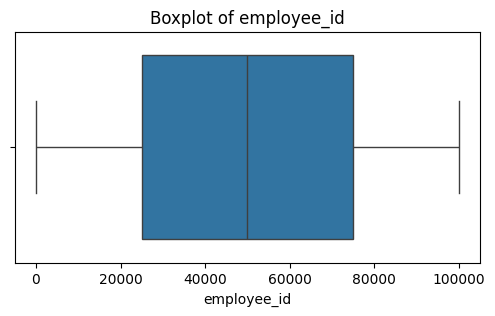

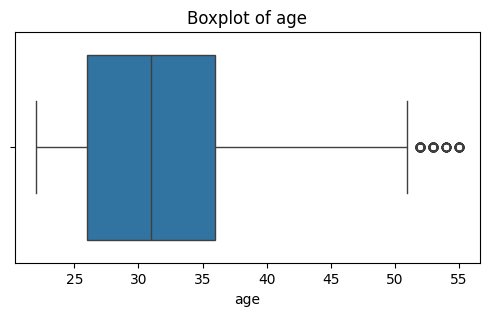

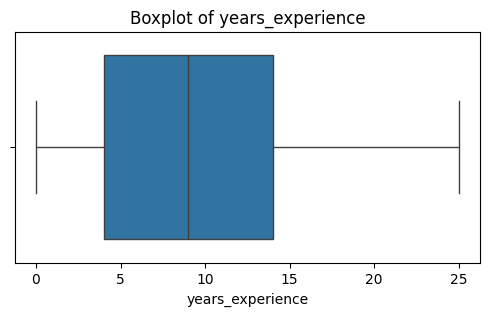

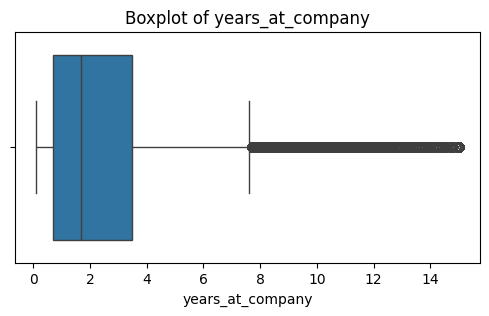

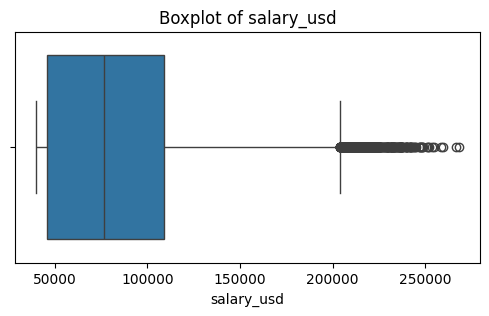

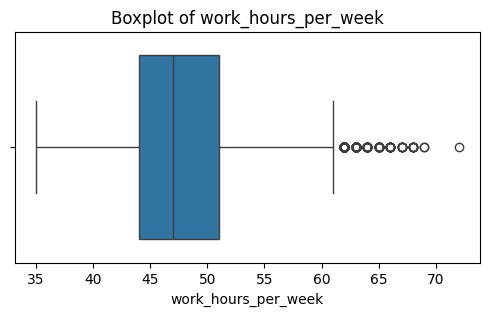

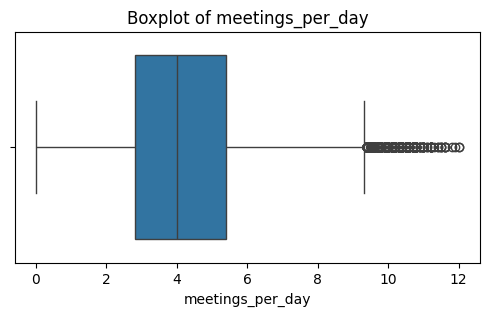

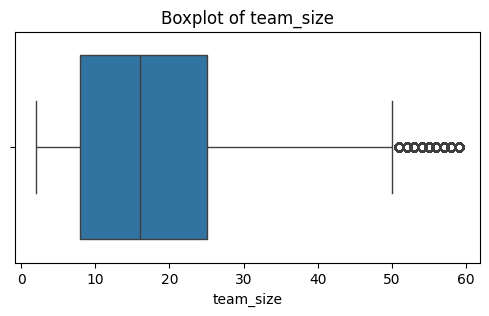

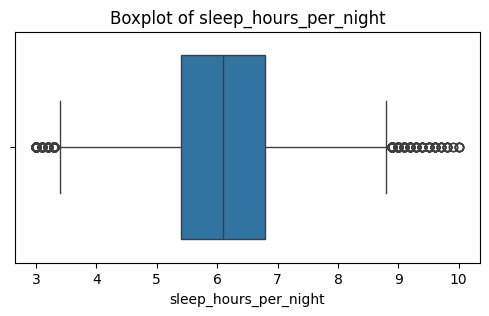

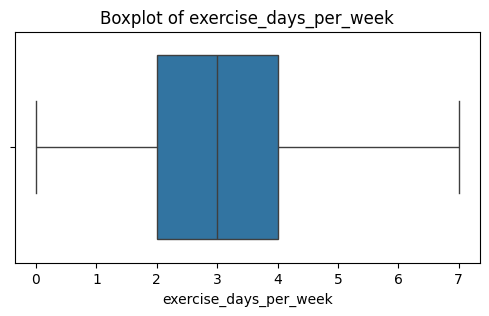

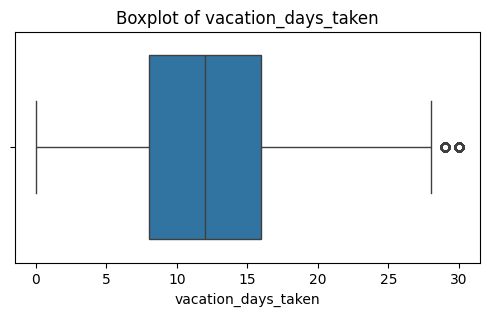

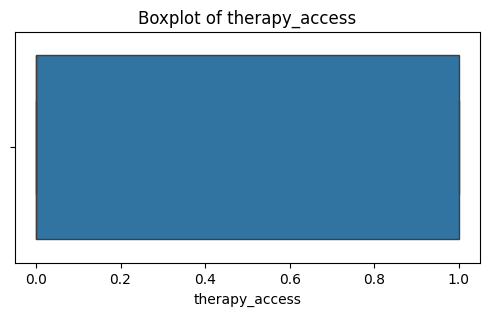

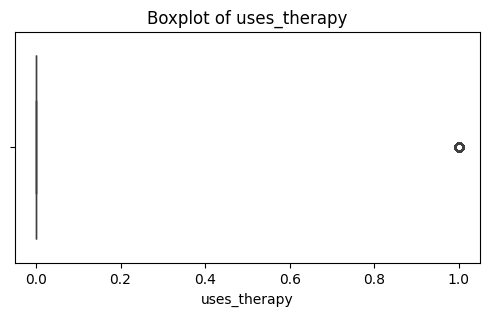

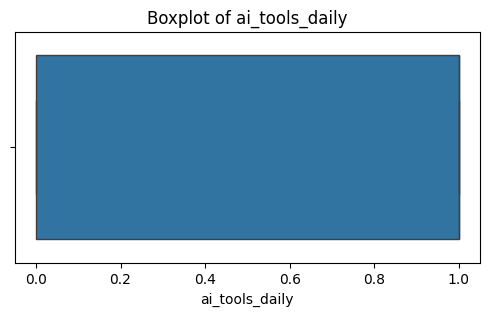

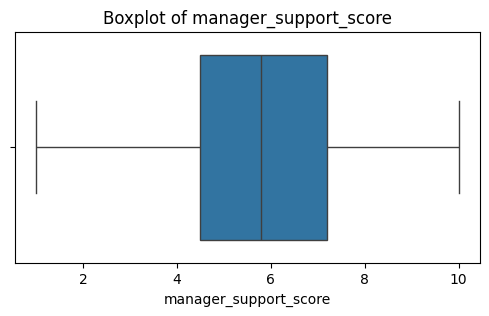

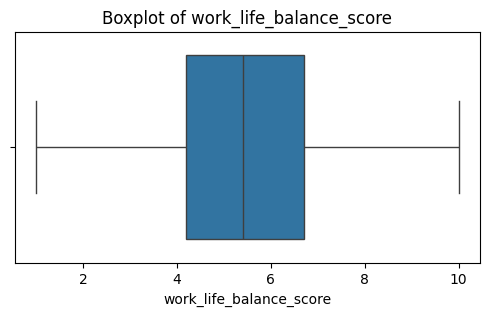

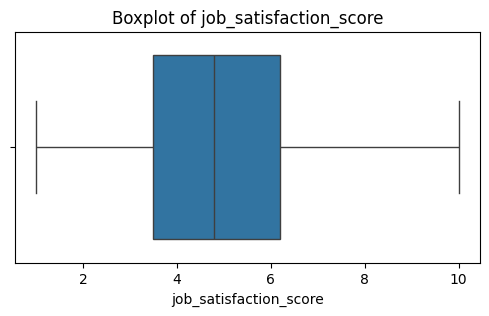

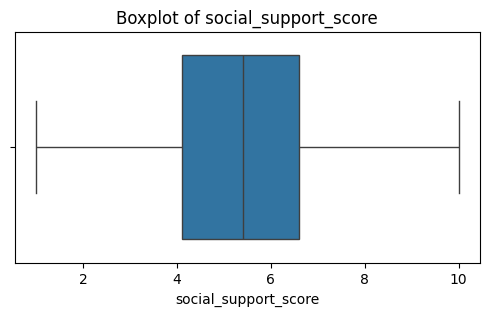

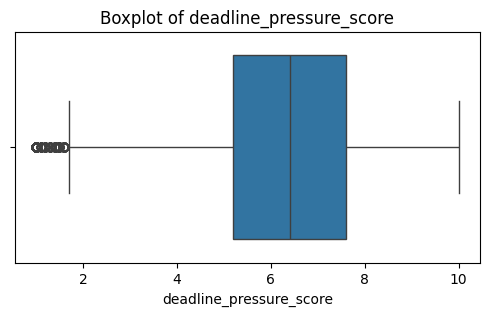

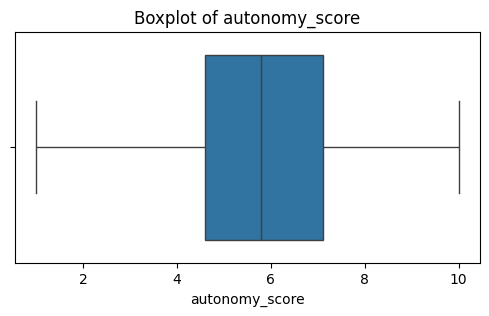

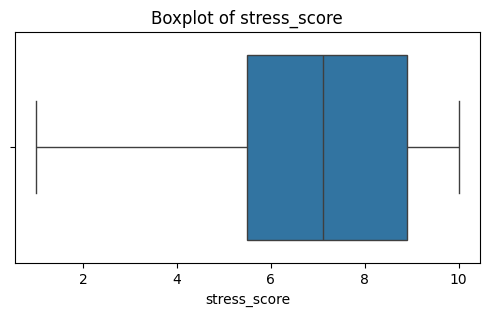

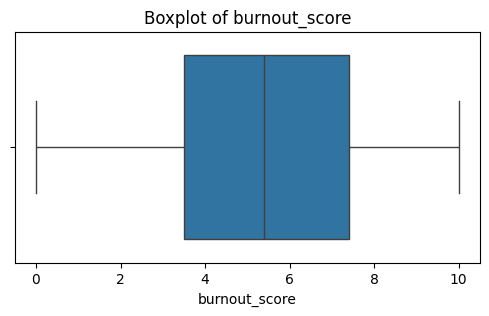

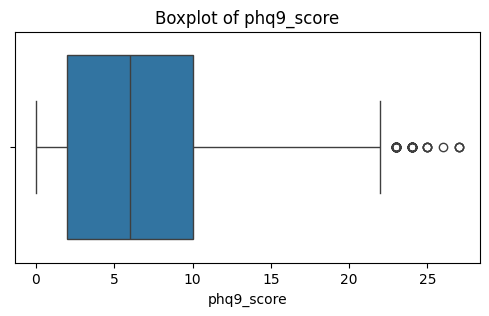

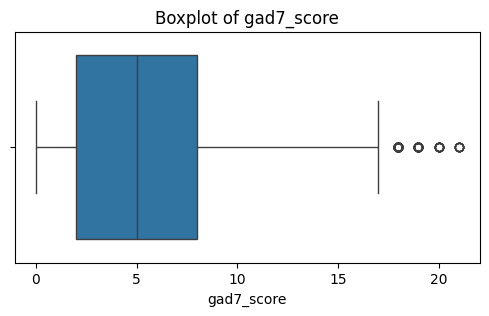

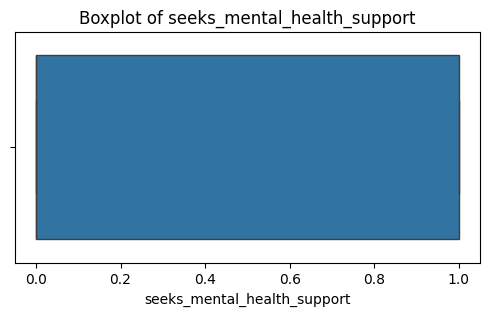

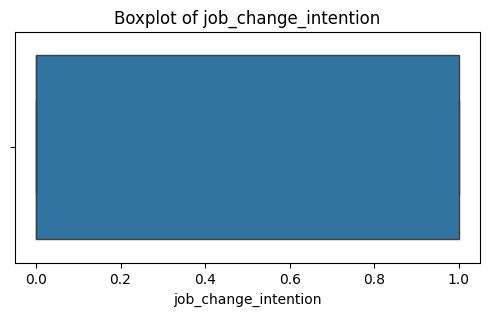

In [5]:
# Boxplot
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

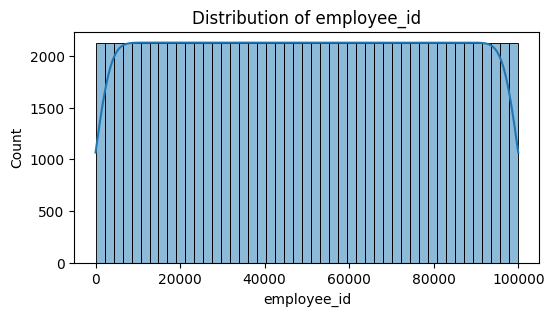

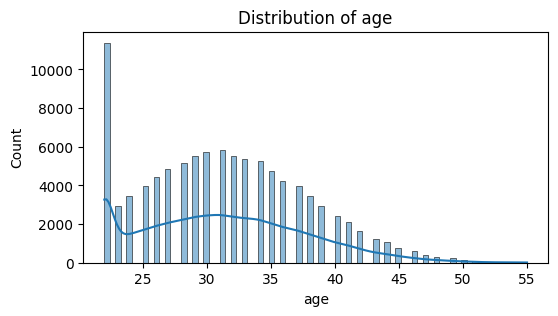

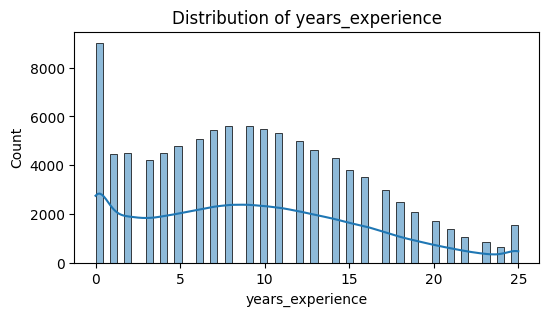

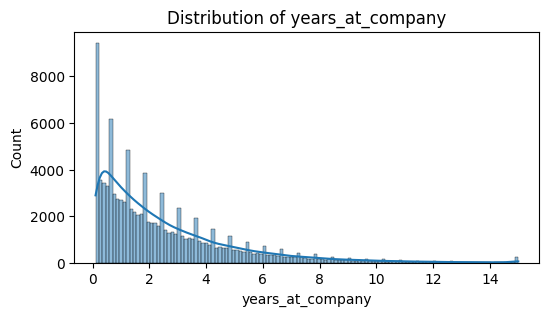

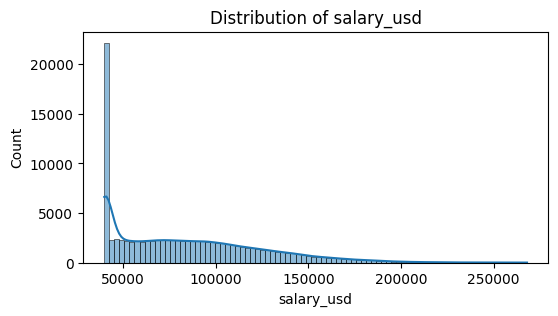

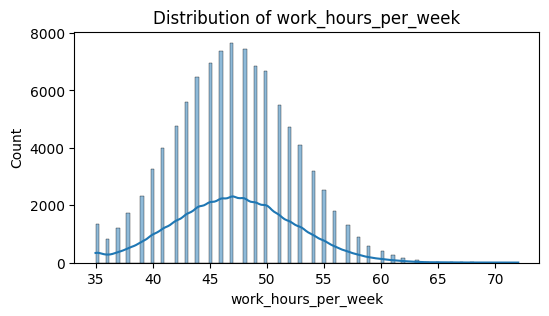

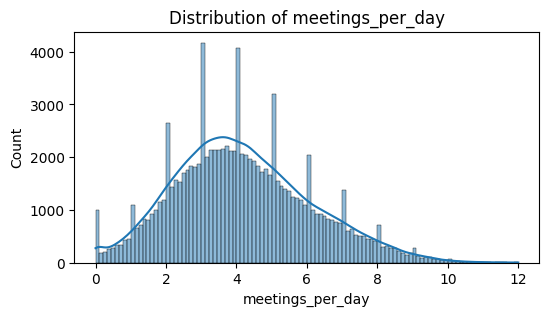

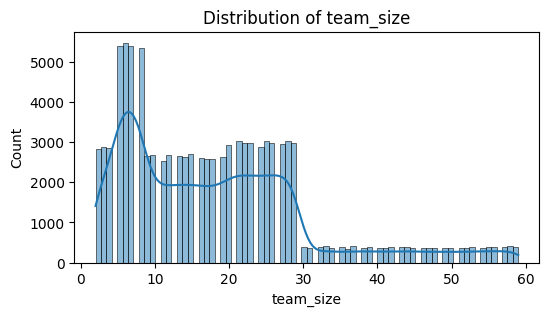

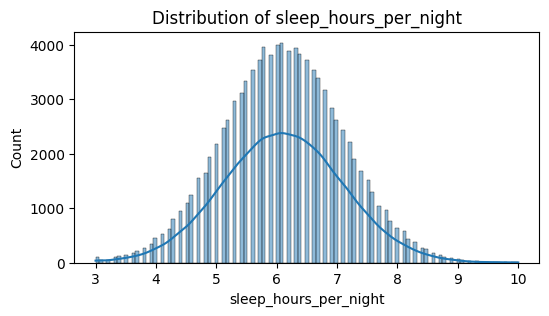

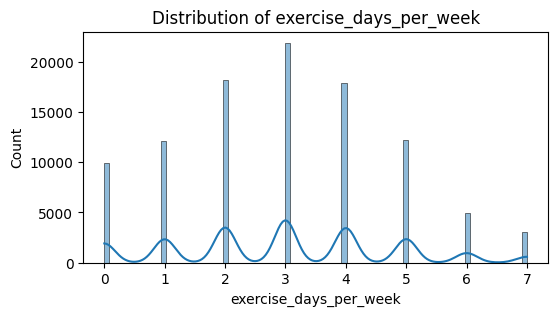

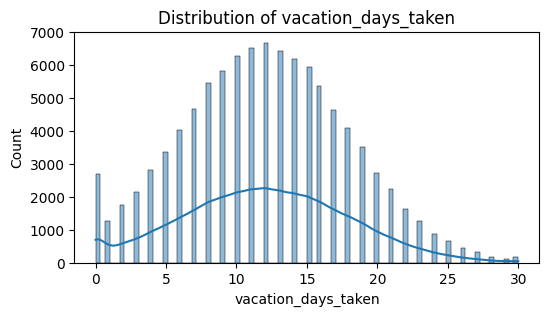

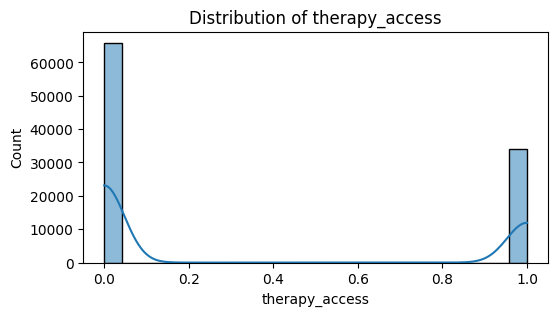

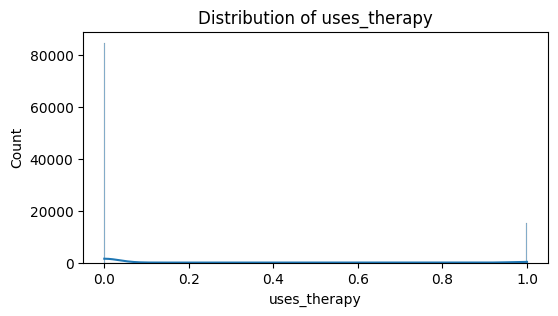

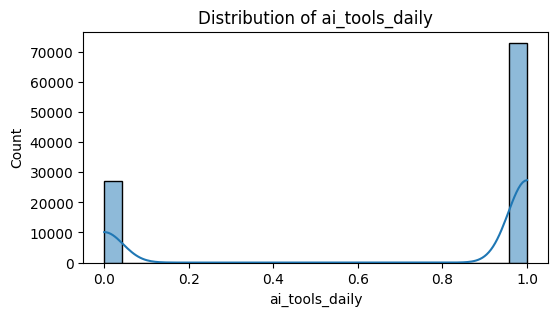

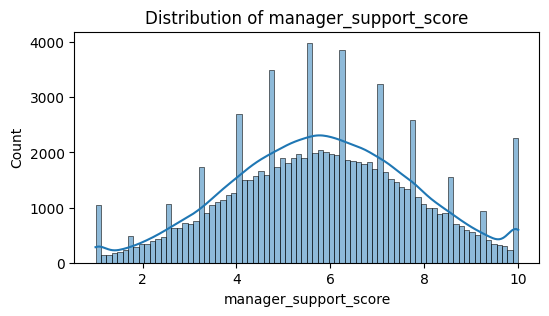

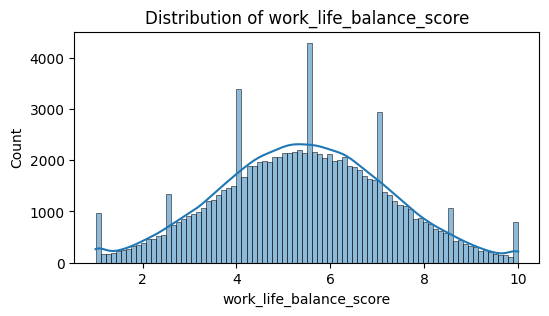

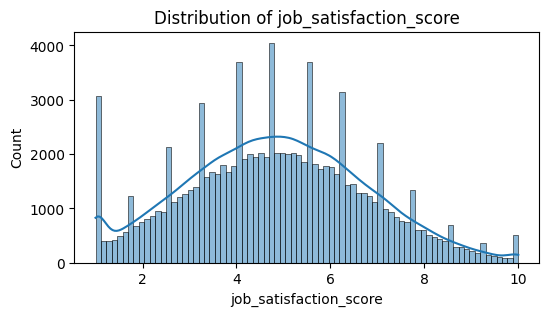

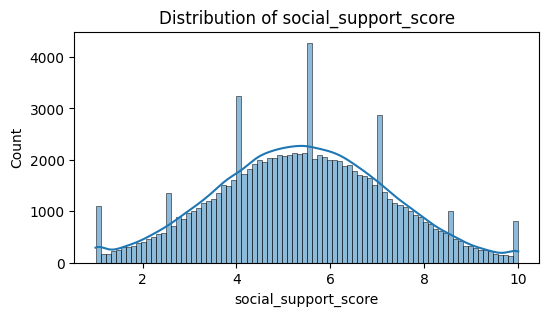

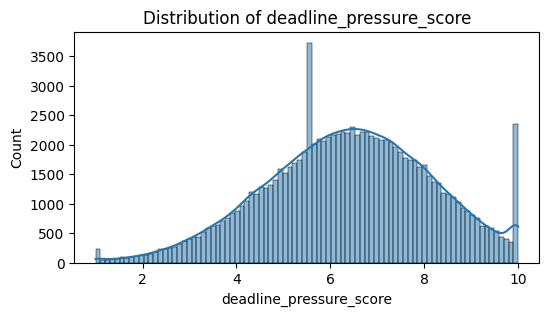

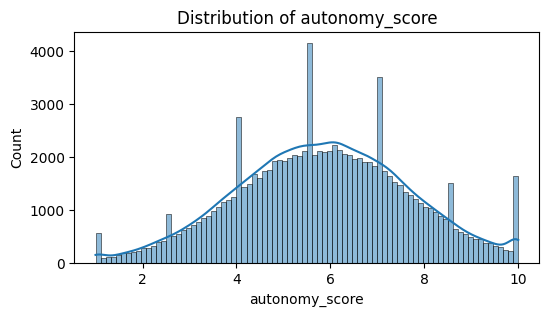

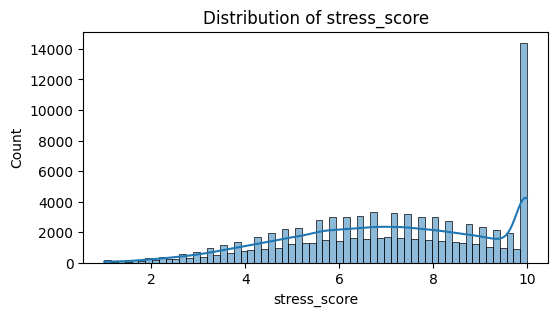

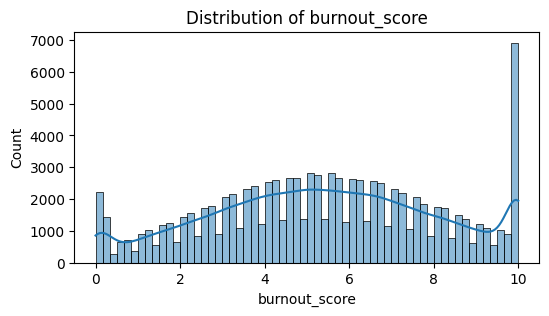

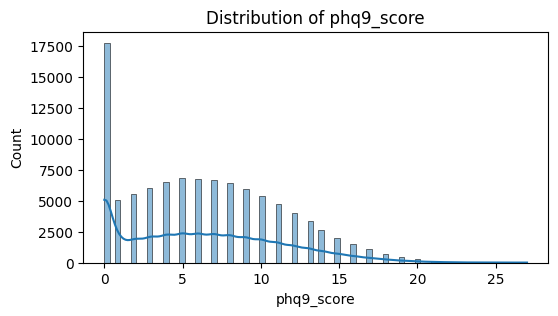

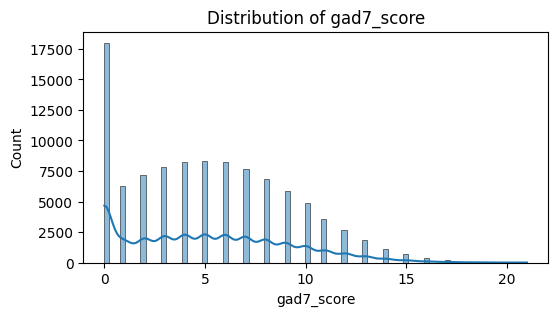

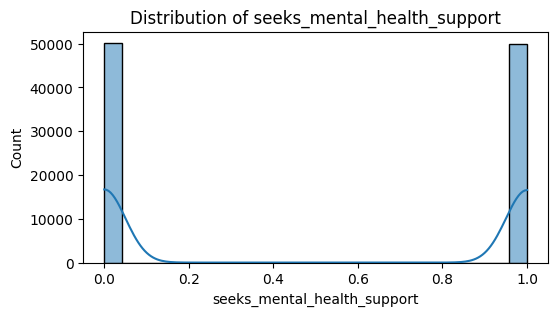

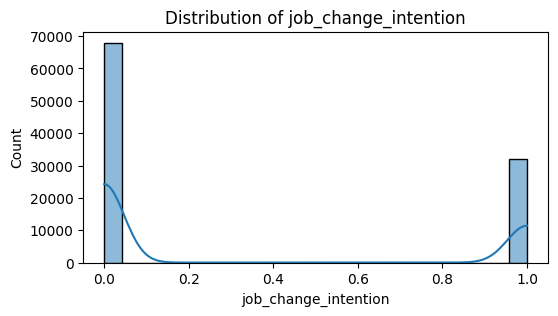

In [6]:
# Visual distribution
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

# Preprocessing

In [7]:
target_column = 'burnout_level'

extra_targets = [
    # other ML targets
    'seeks_mental_health_support',
    'job_change_intention',

    # clinical scores
    'burnout_score',
    'phq9_score',
    'phq9_category',
    'gad7_score',
    'gad7_category'

]

X = df.drop(columns=[target_column] + extra_targets)
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y if y.nunique() > 1 else None)

print(f"Original dataset shape: {df.shape}")
print(f"Training features (X_train) shape: {X_train.shape}")
print(f"Testing features (X_test) shape: {X_test.shape}")
print(f"Training target (y_train) shape: {y_train.shape}")
print(f"Testing target (y_test) shape: {y_test.shape}")

Original dataset shape: (100000, 36)
Training features (X_train) shape: (80000, 28)
Testing features (X_test) shape: (20000, 28)
Training target (y_train) shape: (80000,)
Testing target (y_test) shape: (20000,)


In [8]:
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X_train.select_dtypes(include=['object', 'string', 'bool']).columns

print(f"Numerical columns identified: {list(numerical_cols)}")
print(f"Categorical columns identified: {list(categorical_cols)}")

Numerical columns identified: ['employee_id', 'age', 'years_experience', 'years_at_company', 'salary_usd', 'work_hours_per_week', 'meetings_per_day', 'team_size', 'sleep_hours_per_night', 'exercise_days_per_week', 'vacation_days_taken', 'therapy_access', 'uses_therapy', 'ai_tools_daily', 'manager_support_score', 'work_life_balance_score', 'job_satisfaction_score', 'social_support_score', 'deadline_pressure_score', 'autonomy_score', 'stress_score']
Categorical columns identified: ['gender', 'country', 'job_role', 'seniority_level', 'company_size', 'industry', 'work_mode']


In [9]:
## Outlier Removal Function helper for scenario 3 and 5
def remove_outliers(X, y, numerical_cols):

    df = X.copy()
    df["target"] = y

    mask = pd.Series(True, index=df.index)

    for col in numerical_cols:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        mask &= df[col].between(lower, upper)

    df = df[mask]

    return df.drop(columns=["target"]), df["target"]

# impute with median
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# impute with most frequent and one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

def build_preprocessor():
    return ColumnTransformer([
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Scenario 1 (NO outlier removal)
X_train_raw = X_train
y_train_raw = y_train

preprocessor = build_preprocessor()

def get_preprocessed_data(X_tr, X_te):
    X_tr_p = preprocessor.fit_transform(X_tr)
    X_te_p = preprocessor.transform(X_te)
    return X_tr_p, X_te_p

X_train_cleaned, X_test_cleaned = get_preprocessed_data(X_train_raw, X_test)

print("\nData cleaning applied successfully.")
print(f"Shape of cleaned training data: {X_train_cleaned.shape}")
print(f"Shape of cleaned testing data: {X_test_cleaned.shape}")

# Scenario 2 (WITH outlier removal)
X_train_out, y_train_out = remove_outliers(X_train, y_train, numerical_cols)

X_train_out_p, X_test_out_p = get_preprocessed_data(X_train_out, X_test)

print("\nOutlier applied successfully.")
print(f"Shape of training data: {X_train_out_p.shape}")
print(f"Shape of testing data: {X_test_out_p.shape}")

# using ColumnTransformer returns numpy array, convert back to dataframe
try:
    feature_names = preprocessor.get_feature_names_out()
    X_train_cleaned_df = pd.DataFrame(X_train_cleaned, columns=feature_names, index=X_train.index)
    X_test_cleaned_df = pd.DataFrame(X_test_cleaned, columns=feature_names, index=X_test.index)
    print("\nFirst 5 rows of cleaned training data:")
    display(X_train_cleaned_df.head())
    print("\nFirst 5 rows of cleaned testing data:")
    display(X_test_cleaned_df.head())
except Exception as e:
    print(f"Could not convert cleaned data back to DataFrame for display due to: {e}")
    print("Displaying the numpy array for the first few rows of cleaned training data:")
    print(X_train_cleaned[:5])



Data cleaning applied successfully.
Shape of cleaned training data: (80000, 71)
Shape of cleaned testing data: (20000, 71)

Outlier applied successfully.
Shape of training data: (60737, 71)
Shape of testing data: (20000, 71)

First 5 rows of cleaned training data:


,num__employee_id,num__age,num__years_experience,num__years_at_company,num__salary_usd,num__work_hours_per_week,num__meetings_per_day,num__team_size,num__sleep_hours_per_night,num__exercise_days_per_week,...,cat__industry_E-commerce,cat__industry_Enterprise Software,cat__industry_Fintech,cat__industry_Gaming,cat__industry_Healthcare Tech,cat__industry_SaaS / Cloud,cat__industry_Social Media / AdTech,cat__work_mode_Hybrid,cat__work_mode_On-site,cat__work_mode_Remote
47113,47114.0,35.0,14.0,1.6,94271.0,41.0,5.6,30.0,6.2,3.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
73319,73320.0,30.0,7.0,6.6,56728.0,47.0,4.2,8.0,5.8,4.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
29484,29485.0,28.0,6.0,0.1,134044.0,50.0,1.1,12.0,5.0,5.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
40499,40500.0,30.0,8.0,1.6,57009.0,46.0,3.4,7.0,7.3,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
73135,73136.0,38.0,18.0,10.0,55756.0,47.0,3.7,36.0,6.1,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0



First 5 rows of cleaned testing data:


,num__employee_id,num__age,num__years_experience,num__years_at_company,num__salary_usd,num__work_hours_per_week,num__meetings_per_day,num__team_size,num__sleep_hours_per_night,num__exercise_days_per_week,...,cat__industry_E-commerce,cat__industry_Enterprise Software,cat__industry_Fintech,cat__industry_Gaming,cat__industry_Healthcare Tech,cat__industry_SaaS / Cloud,cat__industry_Social Media / AdTech,cat__work_mode_Hybrid,cat__work_mode_On-site,cat__work_mode_Remote
40848,40849.0,35.0,14.0,1.8,40000.0,39.0,2.3,7.0,6.2,4.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
11806,11807.0,32.0,9.0,3.7,107587.0,48.0,3.8,27.0,5.3,3.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
99645,99646.0,30.0,10.0,2.3,40000.0,42.0,2.9,16.0,5.9,3.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
82890,82891.0,30.0,9.0,6.8,97480.0,56.0,4.6,19.0,6.3,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
60076,60077.0,30.0,10.0,3.2,57677.0,48.0,1.9,6.0,8.0,4.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


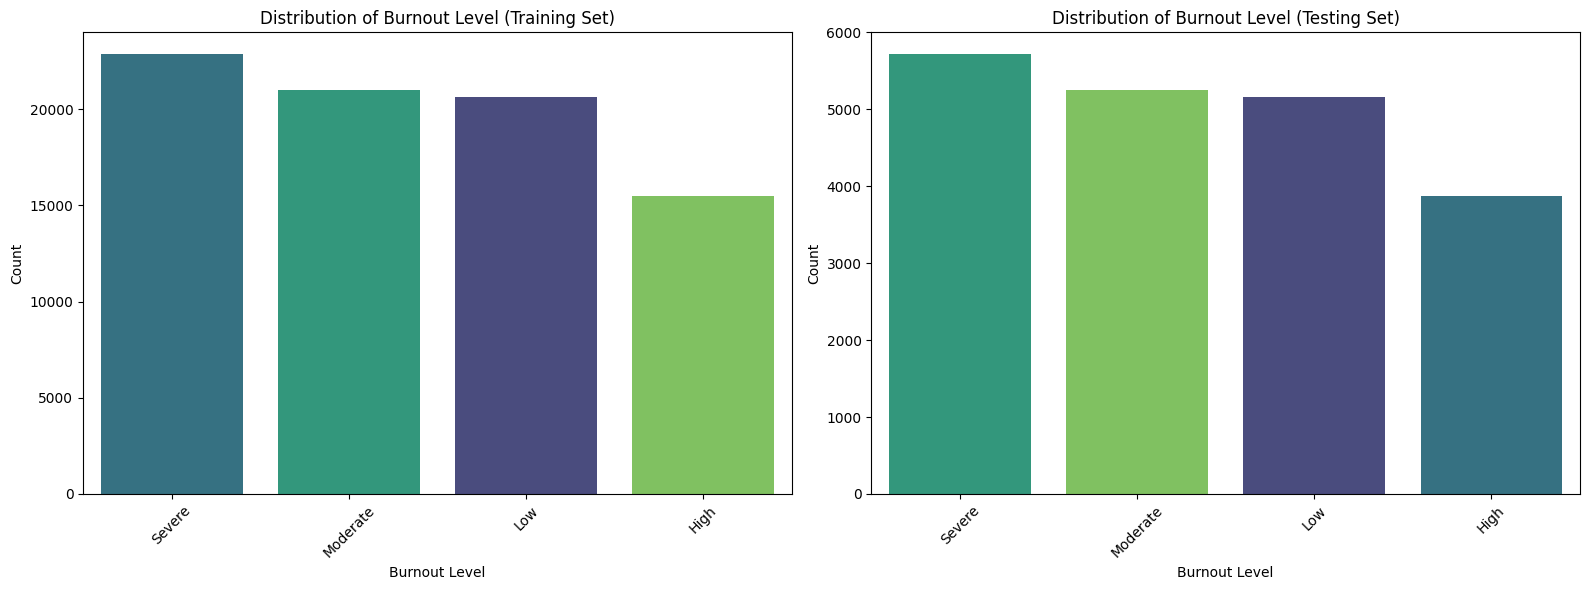

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# distribution in Training Set
sns.countplot(x=y_train, hue=y_train, order=y_train.value_counts().index, palette='viridis', ax=axes[0])
axes[0].set_title('Distribution of Burnout Level (Training Set)')
axes[0].set_xlabel('Burnout Level')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# distribution in Testing Set
sns.countplot(x=y_test, hue=y_test, order=y_test.value_counts().index, palette='viridis', ax=axes[1])
axes[1].set_title('Distribution of Burnout Level (Testing Set)')
axes[1].set_xlabel('Burnout Level')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [11]:
print("\nOriginal Dataset (y) Distribution:")
display(y.value_counts(normalize=False).rename('Count').to_frame().join(y.value_counts(normalize=True).mul(100).rename('Percentage').to_frame().map(lambda x: f'{x:.2f}%')))

print("\nTraining Set (y_train) Distribution:")
display(y_train.value_counts(normalize=False).rename('Count').to_frame().join(y_train.value_counts(normalize=True).mul(100).rename('Percentage').to_frame().map(lambda x: f'{x:.2f}%')))

print("\nTesting Set (y_test) Distribution:")
display(y_test.value_counts(normalize=False).rename('Count').to_frame().join(y_test.value_counts(normalize=True).mul(100).rename('Percentage').to_frame().map(lambda x: f'{x:.2f}%')))


Original Dataset (y) Distribution:


,Count,Percentage
burnout_level,,
Severe,28576,28.58%
Moderate,26255,26.25%
Low,25807,25.81%
High,19362,19.36%



Training Set (y_train) Distribution:


,Count,Percentage
burnout_level,,
Severe,22861,28.58%
Moderate,21004,26.25%
Low,20646,25.81%
High,15489,19.36%



Testing Set (y_test) Distribution:


,Count,Percentage
burnout_level,,
Severe,5715,28.57%
Moderate,5251,26.25%
Low,5161,25.80%
High,3873,19.36%


# Implementation

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train_raw)
y_train_out_enc = le.transform(y_train_out)
y_test_enc = le.transform(y_test)

## Scenario 1: Basic Preprocessing/Raw (No scaler or outlier removal) 

In [13]:
def scenario_raw():
    return X_train_cleaned, X_test_cleaned, y_train_enc, y_test_enc

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import seaborn as sns
import matplotlib.pyplot as plt


def evaluate_model(model_name, y_true, y_pred, class_names):

    acc = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_true,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average='weighted'
    )

    label_order = [1, 2, 0, 3]
    class_order = ['Low', 'Moderate', 'High', 'Severe']

    cm = confusion_matrix(y_true, y_pred, labels=label_order)

    print(f"\n===== {model_name} =====")

    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-score  : {f1:.4f}")

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names
        )
    )

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_order,
        yticklabels=class_order
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix - {model_name}")

    plt.tight_layout()
    plt.show()

    return {
        "Scenario": model_name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

def run_cart_scenario(
    scenario_name,
    X_train_final,
    X_test_final,
    y_train_final,
    y_test_final
):

    X_train_fit, X_val, y_train_fit, y_val = train_test_split(
        X_train_final,
        y_train_final,
        test_size=0.2,
        random_state=42,
        stratify=y_train_final
    )

    model = DecisionTreeClassifier(
        criterion="gini",     
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    )

    model.fit(X_train_fit, y_train_fit)

    y_pred = model.predict(X_test_final)

    metrics = evaluate_model(
        scenario_name,
        y_test_final,
        y_pred,
        le.classes_
    )

    return model, metrics


===== Raw =====
Accuracy  : 0.6261
Precision : 0.6312
Recall    : 0.6261
F1-score  : 0.6282

Classification Report:

              precision    recall  f1-score   support

        High       0.40      0.41      0.41      3873
         Low       0.78      0.71      0.74      5161
    Moderate       0.50      0.53      0.51      5251
      Severe       0.78      0.79      0.78      5715

    accuracy                           0.63     20000
   macro avg       0.61      0.61      0.61     20000
weighted avg       0.63      0.63      0.63     20000



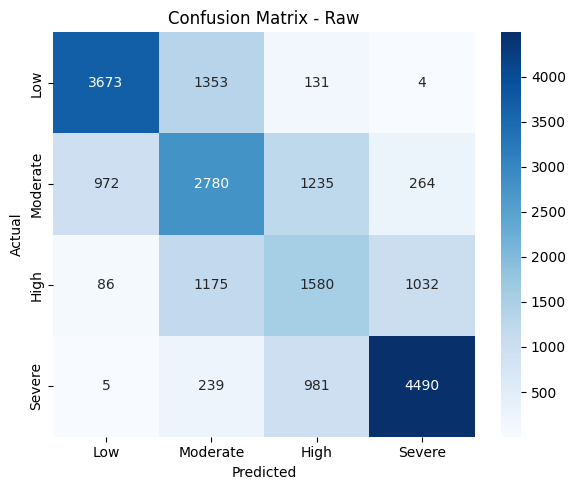

In [16]:
results = {}

models = {}

X_train_final, X_test_final, y_train_final, y_test_final = scenario_raw()

model, metrics = run_cart_scenario(
    "Raw",
    X_train_final,
    X_test_final,
    y_train_final,
    y_test_final
)

results["Raw"] = metrics

## Scenario 2: Standard Scaler

In [17]:
from sklearn.preprocessing import StandardScaler

def scenario_scaler():

    X_tr, X_te = get_preprocessed_data(X_train_raw, X_test)

    scaler = StandardScaler(with_mean=False)

    X_train_final = scaler.fit_transform(X_tr)
    X_test_final = scaler.transform(X_te)

    return X_train_final, X_test_final, y_train_enc, y_test_enc


===== Scaler =====
Accuracy  : 0.6261
Precision : 0.6312
Recall    : 0.6261
F1-score  : 0.6282

Classification Report:

              precision    recall  f1-score   support

        High       0.40      0.41      0.41      3873
         Low       0.78      0.71      0.74      5161
    Moderate       0.50      0.53      0.51      5251
      Severe       0.78      0.79      0.78      5715

    accuracy                           0.63     20000
   macro avg       0.61      0.61      0.61     20000
weighted avg       0.63      0.63      0.63     20000



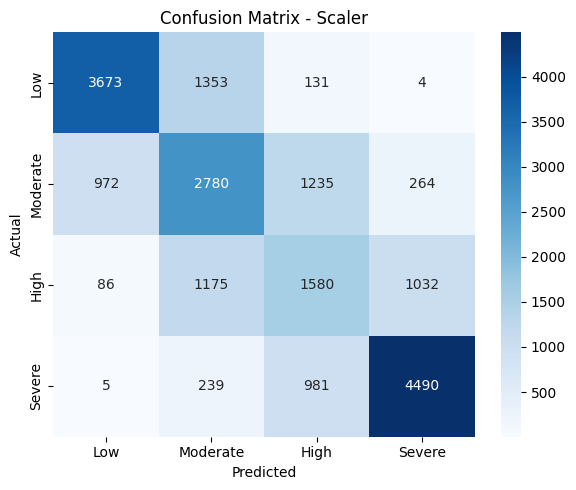

In [18]:
X_train_final, X_test_final, y_train_final, y_test_final = scenario_scaler()

model, metrics = run_cart_scenario(
    "Scaler",
    X_train_final,
    X_test_final,
    y_train_final,
    y_test_final
)

results["Scaler"] = metrics

## Scenario 3: Outlier Removal

In [19]:
def scenario_outlier():
    return X_train_out_p, X_test_out_p, y_train_out_enc, y_test_enc


===== Outlier =====
Accuracy  : 0.6273
Precision : 0.6261
Recall    : 0.6273
F1-score  : 0.6266

Classification Report:

              precision    recall  f1-score   support

        High       0.40      0.39      0.40      3873
         Low       0.76      0.74      0.75      5161
    Moderate       0.50      0.51      0.51      5251
      Severe       0.77      0.79      0.78      5715

    accuracy                           0.63     20000
   macro avg       0.61      0.61      0.61     20000
weighted avg       0.63      0.63      0.63     20000



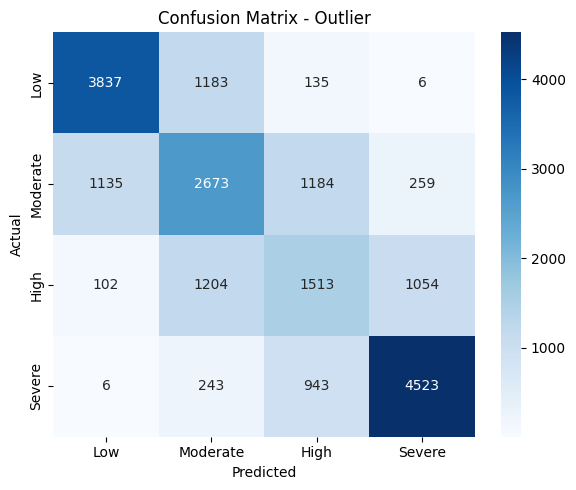

In [20]:
X_train_final, X_test_final, y_train_final, y_test_final = scenario_outlier()

model, metrics = run_cart_scenario(
    "Outlier",
    X_train_final,
    X_test_final,
    y_train_final,
    y_test_final
)

results["Outlier"] = metrics

## Scenario 4: SMOTE

In [21]:
from imblearn.over_sampling import SMOTE

def scenario_smote():

    X_tr, X_te = get_preprocessed_data(X_train_raw, X_test)

    smote = SMOTE(random_state=42)

    X_train_final, y_train_final = smote.fit_resample(X_tr, y_train_enc)

    return X_train_final, X_te, y_train_final, y_test_enc


===== SMOTE =====
Accuracy  : 0.6203
Precision : 0.6312
Recall    : 0.6203
F1-score  : 0.6237

Classification Report:

              precision    recall  f1-score   support

        High       0.39      0.48      0.43      3873
         Low       0.74      0.77      0.76      5161
    Moderate       0.51      0.45      0.48      5251
      Severe       0.80      0.73      0.76      5715

    accuracy                           0.62     20000
   macro avg       0.61      0.61      0.61     20000
weighted avg       0.63      0.62      0.62     20000



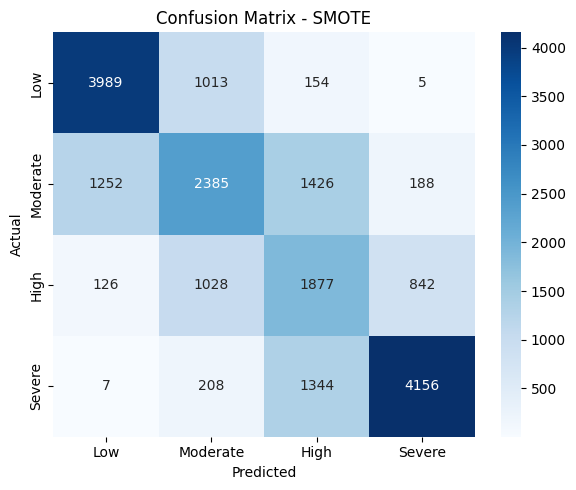

In [22]:
X_train_final, X_test_final, y_train_final, y_test_final = scenario_smote()

model, metrics = run_cart_scenario(
    "SMOTE",
    X_train_final,
    X_test_final,
    y_train_final,
    y_test_final
)

results["SMOTE"] = metrics

## Scenario 5: Mix all Scenarios

In [23]:
def scenario_mix():
    X_tr, X_te = get_preprocessed_data(X_train_raw, X_test)

    scaler = StandardScaler(with_mean=False)
    X_scaled = scaler.fit_transform(X_tr)
    X_test_final = scaler.transform(X_te)

    df = pd.DataFrame(X_scaled)

    outlier_count = np.zeros(len(df))

    for col in df.columns:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outlier_count += ~df[col].between(lower, upper)

    mask = outlier_count <= 2   

    X_filtered = df[mask].values
    y_filtered = y_train_enc[mask.values]

    if len(X_filtered) < 10:
        print("Warning: too few samples after filtering. Skipping outlier step.")
        X_filtered = X_scaled
        y_filtered = y_train_enc

    smote = SMOTE(random_state=42)
    X_train_final, y_train_final = smote.fit_resample(X_filtered, y_filtered)

    return X_train_final, X_test_final, y_train_final, y_test_enc


===== Mix =====
Accuracy  : 0.5747
Precision : 0.5687
Recall    : 0.5747
F1-score  : 0.5701

Classification Report:

              precision    recall  f1-score   support

        High       0.34      0.36      0.35      3873
         Low       0.70      0.67      0.68      5161
    Moderate       0.45      0.39      0.42      5251
      Severe       0.71      0.81      0.76      5715

    accuracy                           0.57     20000
   macro avg       0.55      0.56      0.55     20000
weighted avg       0.57      0.57      0.57     20000



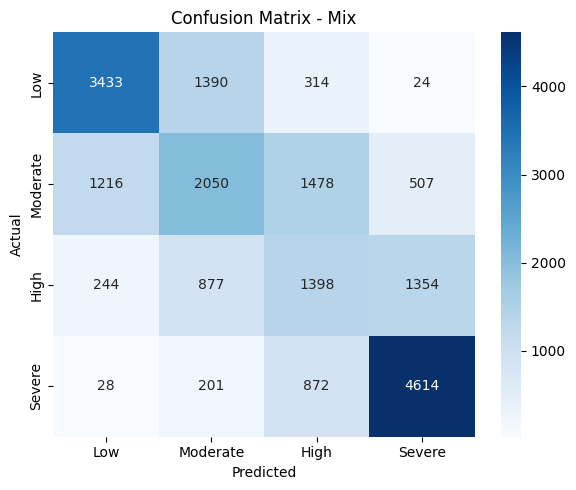

In [24]:
X_train_final, X_test_final, y_train_final, y_test_final = scenario_mix()

model, metrics = run_cart_scenario(
    "Mix",
    X_train_final,
    X_test_final,
    y_train_final,
    y_test_final
)

results["Mix"] = metrics

# Evaluation

In [25]:
results_df = pd.DataFrame(results)
results_df = results_df.T
results_df.index.name = "Scenario"

results_df = results_df.sort_values("F1", ascending=False)

display(results_df)

,Scenario,Accuracy,Precision,Recall,F1
Scenario,,,,,
Raw,Raw,0.62615,0.631219,0.62615,0.628216
Scaler,Scaler,0.62615,0.631219,0.62615,0.628216
Outlier,Outlier,0.6273,0.626096,0.6273,0.626643
SMOTE,SMOTE,0.62035,0.631158,0.62035,0.623704
Mix,Mix,0.57475,0.568668,0.57475,0.570054


# Visualization

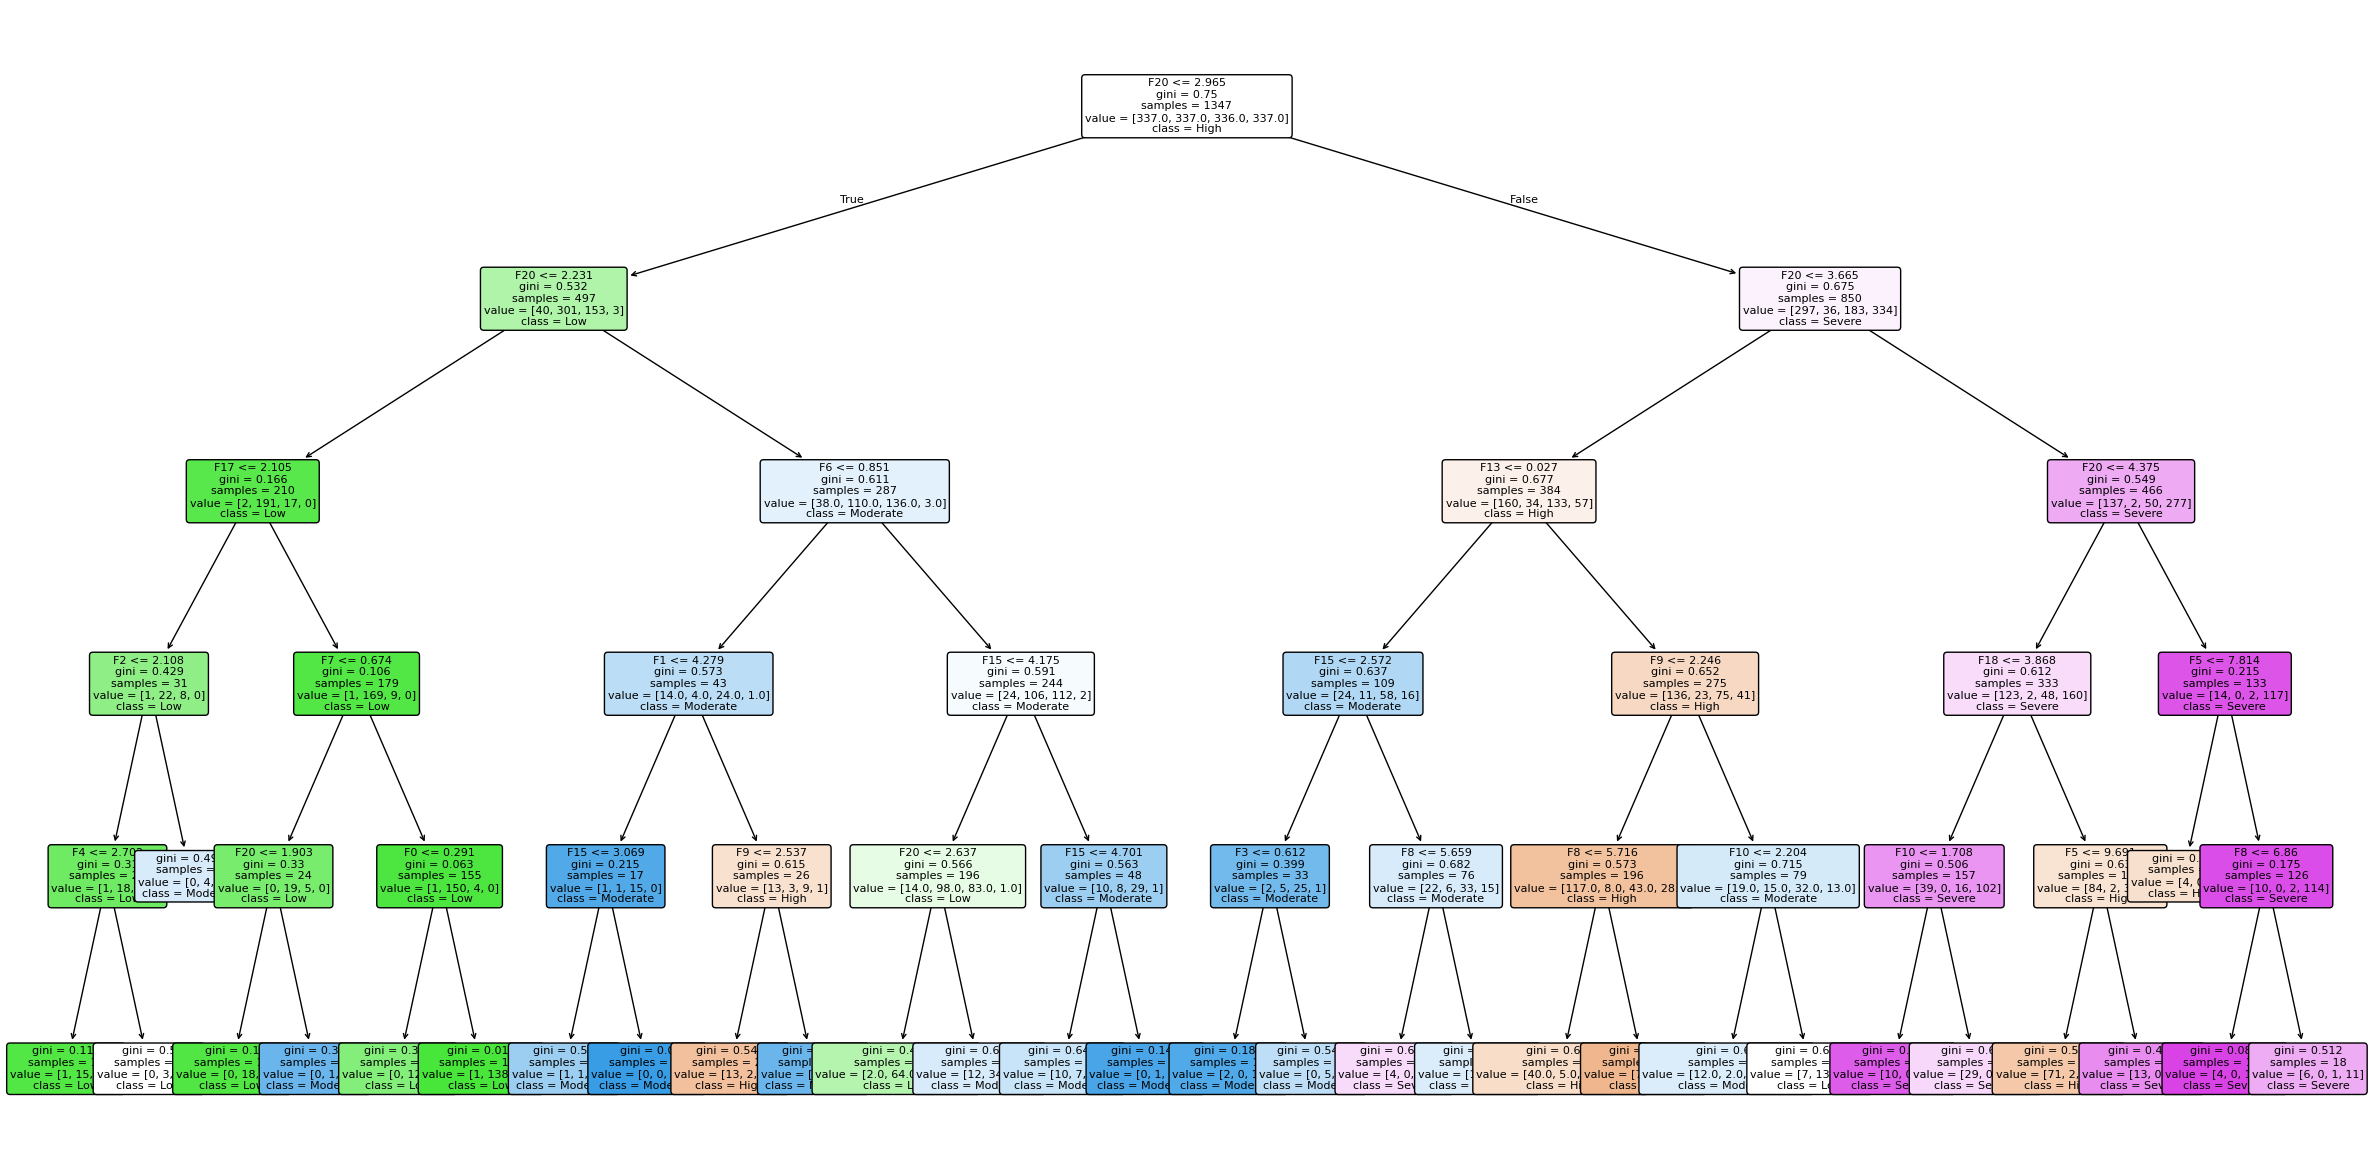

In [26]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

feature_names = [f"F{i}" for i in range(X_train_final.shape[1])]

plt.figure(figsize=(30,15))

plot_tree(
    model,
    feature_names=feature_names,
    class_names=[str(c) for c in le.classes_],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

In [27]:
from sklearn.tree import export_text

rules = export_text(
    model,
    feature_names=[f"F{i}" for i in range(X_train_final.shape[1])]
)

print(rules)

|--- F20 <= 2.96
|   |--- F20 <= 2.23
|   |   |--- F17 <= 2.11
|   |   |   |--- F2 <= 2.11
|   |   |   |   |--- F4 <= 2.70
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- F4 >  2.70
|   |   |   |   |   |--- class: 1
|   |   |   |--- F2 >  2.11
|   |   |   |   |--- class: 2
|   |   |--- F17 >  2.11
|   |   |   |--- F7 <= 0.67
|   |   |   |   |--- F20 <= 1.90
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- F20 >  1.90
|   |   |   |   |   |--- class: 2
|   |   |   |--- F7 >  0.67
|   |   |   |   |--- F0 <= 0.29
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- F0 >  0.29
|   |   |   |   |   |--- class: 1
|   |--- F20 >  2.23
|   |   |--- F6 <= 0.85
|   |   |   |--- F1 <= 4.28
|   |   |   |   |--- F15 <= 3.07
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- F15 >  3.07
|   |   |   |   |   |--- class: 2
|   |   |   |--- F1 >  4.28
|   |   |   |   |--- F9 <= 2.54
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- F9 >  2.54
|   |   |   |   |   |--- class: 2
|   |